In [54]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

In [55]:
df = pd.read_csv("ipl_2008_2024_complete.csv")

df.head()

,match_id,innings,total_runs,extras,wickets,balls_bowled,boundaries_4,boundaries_6,dot_balls,batting_team,...,date,venue,city,toss_winner,toss_decision,winner,player_of_match,method,season,toss_win_match_win
0,335982,1,205,17,3,124,15,14,45,Kolkata Knight Riders,...,2008-04-18,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,NaN,2008.0,0.0
1,335982,2,63,19,10,101,3,3,65,Royal Challengers Bangalore,...,2008-04-18,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,NaN,2008.0,0.0
2,335983,1,234,6,5,124,20,16,39,Chennai Super Kings,...,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,NaN,2008.0,1.0
3,335983,2,196,11,4,124,18,9,33,Kings XI Punjab,...,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,NaN,2008.0,1.0
4,335984,1,122,7,8,122,14,3,60,Rajasthan Royals,...,2008-04-19,Feroz Shah Kotla,Delhi,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,NaN,2008.0,0.0


In [56]:
df = df.dropna(subset=['winner'])

df.shape

(2152, 28)

In [57]:
current_teams = [
'Mumbai Indians',
'Chennai Super Kings',
'Royal Challengers Bangalore',
'Kolkata Knight Riders',
'Sunrisers Hyderabad',
'Rajasthan Royals',
'Delhi Capitals',
'Punjab Kings',
'Gujarat Titans',
'Lucknow Super Giants'
]

df = df[df['batting_team'].isin(current_teams)]
df = df[df['bowling_team'].isin(current_teams)]

In [58]:
team_wins = df['winner'].value_counts()

total_matches = df['batting_team'].value_counts() + df['bowling_team'].value_counts()

win_rate = team_wins / total_matches
win_rate = win_rate.fillna(0)

df['batting_win_rate'] = df['batting_team'].map(win_rate)
df['bowling_win_rate'] = df['bowling_team'].map(win_rate)

In [59]:
def head_to_head(team1, team2):
    
    matches = df[
        ((df['batting_team'] == team1) & (df['bowling_team'] == team2)) |
        ((df['batting_team'] == team2) & (df['bowling_team'] == team1))
    ]

    team1_wins = sum(matches['winner'] == team1)
    team2_wins = sum(matches['winner'] == team2)

    return team1_wins, team2_wins


df['h2h_batting'] = 0
df['h2h_bowling'] = 0

for i,row in df.iterrows():
    
    t1 = row['batting_team']
    t2 = row['bowling_team']

    w1,w2 = head_to_head(t1,t2)

    df.at[i,'h2h_batting'] = w1
    df.at[i,'h2h_bowling'] = w2

In [60]:
venue_stats = df.groupby(['venue','winner']).size().unstack(fill_value=0)

def venue_win_rate(team, venue):

    if venue in venue_stats.index and team in venue_stats.columns:
        wins = venue_stats.loc[venue,team]
        total = venue_stats.loc[venue].sum()
        return wins / total

    return 0


df['batting_venue_rate'] = df.apply(lambda x: venue_win_rate(x['batting_team'],x['venue']),axis=1)

df['bowling_venue_rate'] = df.apply(lambda x: venue_win_rate(x['bowling_team'],x['venue']),axis=1)

In [61]:
le = LabelEncoder()

df['batting_team'] = le.fit_transform(df['batting_team'])
df['bowling_team'] = le.fit_transform(df['bowling_team'])
df['venue'] = le.fit_transform(df['venue'])
df['city'] = le.fit_transform(df['city'])
df['toss_winner'] = le.fit_transform(df['toss_winner'])
df['toss_decision'] = le.fit_transform(df['toss_decision'])
df['winner'] = le.fit_transform(df['winner'])

In [62]:
features = [
'batting_team',
'bowling_team',
'venue',
'city',
'toss_winner',
'toss_decision',
'batting_win_rate',
'bowling_win_rate',
'h2h_batting',
'h2h_bowling',
'batting_venue_rate',
'bowling_venue_rate'
]

X = df[features]
y = df['winner']

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [68]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Improved Model Accuracy:", accuracy)

Improved Model Accuracy: 0.5720164609053497


In [69]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.59259259 0.56790123 0.54320988 0.53497942 0.49173554]
Average Accuracy: 0.5460837329524197


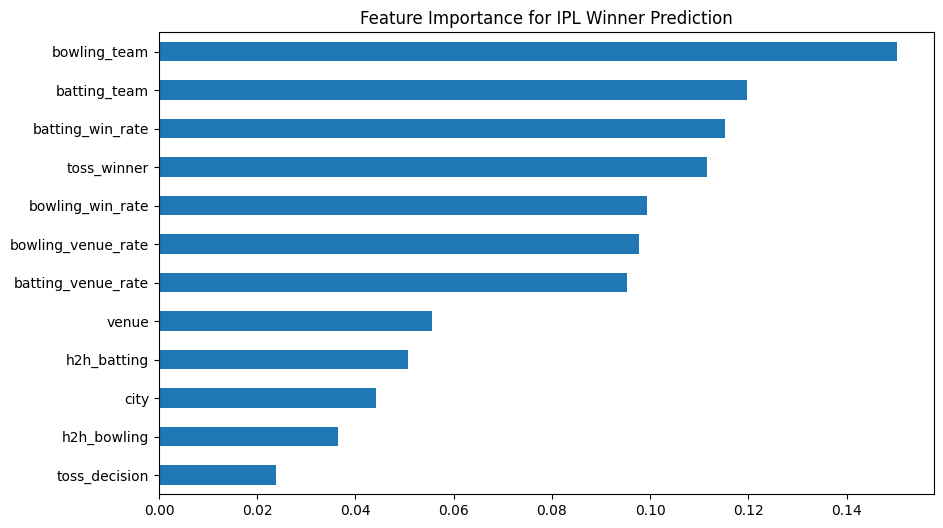

In [70]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Feature Importance for IPL Winner Prediction")

plt.show()

In [71]:
import pickle

with open("ipl_winner_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!
